Project : Driver Drowsiness and distraction detection system

Author : Shyjumon Nankandiyil
E-mail : snankandiyil@sandiego.edu

Download and Extract Dataset

In [ ]:
# Install Kaggle API
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()
{"username":"shyjumonkanaran","key":"855baed5a2f1543e070b2576f0dffef8"}

Saving kaggle.json to kaggle (1).json


{'username': 'shyjumonkanaran', 'key': '855baed5a2f1543e070b2576f0dffef8'}

In [ ]:
# Save kaggle.json to the right location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete.")

Kaggle API setup complete.


In [ ]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 4.00G/4.00G [01:27<00:00, 34.8MB/s]
100% 4.00G/4.00G [01:27<00:00, 49.3MB/s]


In [ ]:
# Unzip files
!mkdir extracted_imgs
!unzip -q state-farm-distracted-driver-detection.zip -d extracted_imgs

# Unzip any inner zips
import os
for f in os.listdir("extracted_imgs"):
    if f.endswith(".zip"):
        print("Unzipping:", f)
        !unzip -q extracted_imgs/$f -d extracted_imgs

Phase 2: Deep Learning Model Training (Transfer Learning)
Import Libraries and Define Configuration

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os
import zipfile

# --- 1. Configuration and Data Setup ---
IMG_SIZE = 224  # Required input size for MobileNetV2
BATCH_SIZE = 64
NUM_CLASSES = 10  # c0 to c9
EPOCHS = 15
MODEL_SAVE_PATH = 'distraction_model.h5'

# --- Extraction Logic ---
zip_path = '/content/state-farm-distracted-driver-detection.zip'  # adjust to your actual zip file
extract_path = '/content/extracted_imgs'  # keep consistent

# Extract only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Define train directory AFTER extraction
TRAIN_DIR = os.path.join(extract_path, 'imgs/train')

# Verify extraction
print("\nAfter extraction:")
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Contents of extract_path:", os.listdir(extract_path))


After extraction:
Train dir exists: True
Contents of extract_path: ['driver_imgs_list.csv', 'imgs', 'sample_submission.csv']


Data Generators with Augmentation

In [ ]:
# --- 2. Data Generators with Augmentation ---
# Extensive augmentation is crucial for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% for validation
)

print("Setting up Data Generators...")

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# Print class mapping for user reference
print("\nClass Mapping for reference:")
print(train_generator.class_indices)

Setting up Data Generators...
Found 17943 images belonging to 10 classes.
Found 4481 images belonging to 10 classes.

Class Mapping for reference:
{'c0': 0, 'c1': 1, 'c2': 2, 'c3': 3, 'c4': 4, 'c5': 5, 'c6': 6, 'c7': 7, 'c8': 8, 'c9': 9}


Transfer Learning Model Construction (MobileNetV2)

In [ ]:
# --- 3. Transfer Learning Model Construction (MobileNetV2) ---

# Load the base MobileNetV2 model pre-trained on ImageNet
print("\nLoading MobileNetV2 for Transfer Learning...")
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False, # Exclude the top classification layer
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model weights
base_model.trainable = False
print(f"Base model loaded and frozen. Total trainable parameters: {len(base_model.trainable_variables)}")

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces feature map to a single vector
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# --- 4. Compile and Train (Phase 1: Head Training) ---

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Higher LR for training new head
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Loading MobileNetV2 for Transfer Learning...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model loaded and frozen. Total trainable parameters: 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,918,986 (11.14 MB)

 Trainable params: 661,002 (2.52 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Run Phase 1 Training

In [ ]:
print("\n--- Starting Phase 1: Training Classification Head ---")
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5, # Train head for 5 epochs
    verbose=1
)


--- Starting Phase 1: Training Classification Head ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 1229s 4s/step - accuracy: 0.3461 - loss: 1.9384 - val_accuracy: 0.6601 - val_loss: 1.0007
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 1212s 4s/step - accuracy: 0.6300 - loss: 1.0834 - val_accuracy: 0.7425 - val_loss: 0.7630
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 1240s 4s/step - accuracy: 0.6852 - loss: 0.9098 - val_accuracy: 0.7992 - val_loss: 0.6366
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 1267s 4s/step - accuracy: 0.7346 - loss: 0.7730 - val_accuracy: 0.8183 - val_loss: 0.5730
Epoch 5/5
185/281 ━━━━━━━━━━━━━━━━━━━━ 5:40 4s/step - accuracy: 0.7370 - loss: 0.7537

Phase 2 Fine-Tuning Setup

In [ ]:
# --- 5. Fine-Tuning (Phase 2: Unfreeze and Train) ---

# Unfreeze the base model for fine-tuning
base_model.trainable = True
# Freeze layers below a certain point (e.g., first 100 layers)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low LR to avoid destroying pre-trained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,918,986 (11.14 MB)

 Trainable params: 2,522,442 (9.62 MB)

 Non-trainable params: 396,544 (1.51 MB)

Run Phase 2 Training

In [ ]:
#print("\n--- Starting Phase 2: Fine-Tuning Top Layers ---")
#history_fine_tune = model.fit(
#    train_generator,
#    validation_data=validation_generator,
#    epochs=EPOCHS,
#    initial_epoch=history.epoch[-1],
#   verbose=1
#)
print("\n--- Starting Phase 2: Fine-Tuning Top Layers ---")
history_fine_tune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=history.epoch[-1] + 5,   # run 5 more epochs
    initial_epoch=history.epoch[-1],
    verbose=1
)


--- Starting Phase 2: Fine-Tuning Top Layers ---
Epoch 5/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1734s 6s/step - accuracy: 0.9121 - loss: 0.2744 - val_accuracy: 0.9373 - val_loss: 0.1959
Epoch 6/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1709s 6s/step - accuracy: 0.9233 - loss: 0.2371 - val_accuracy: 0.9464 - val_loss: 0.1616
Epoch 7/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1745s 6s/step - accuracy: 0.9365 - loss: 0.2050 - val_accuracy: 0.9505 - val_loss: 0.1500
Epoch 8/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1699s 6s/step - accuracy: 0.9384 - loss: 0.1953 - val_accuracy: 0.9547 - val_loss: 0.1357
Epoch 9/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1703s 6s/step - accuracy: 0.9464 - loss: 0.1739 - val_accuracy: 0.9645 - val_loss: 0.1138


Save Model and Plot Results


Distraction model saved successfully to distraction_model.h5


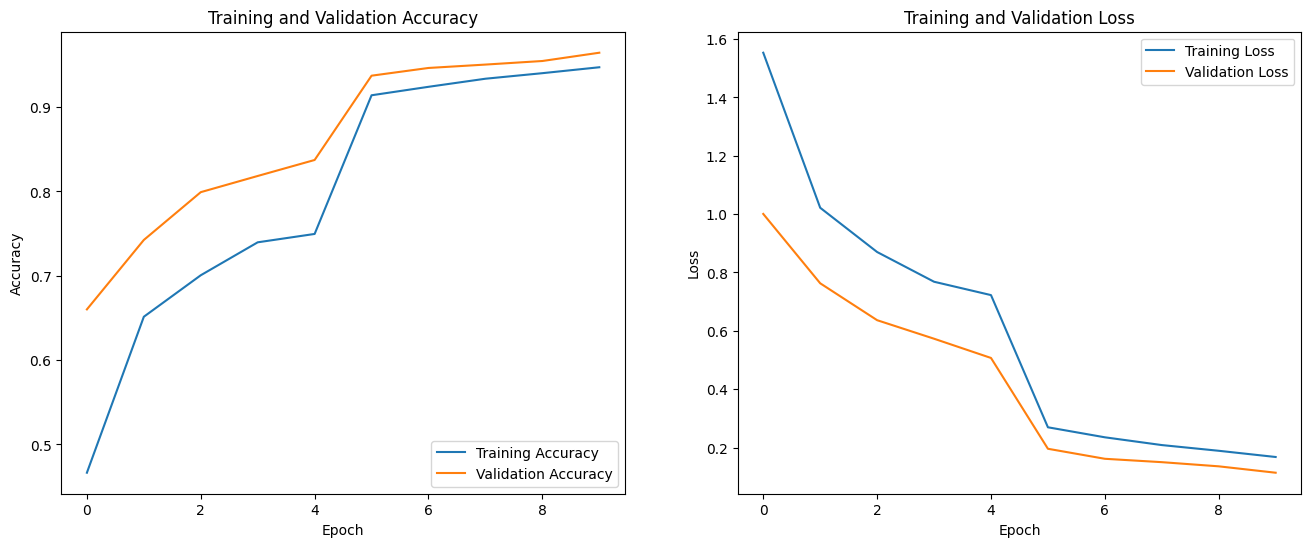

In [ ]:
# --- 6. Save Model and Plot Results ---

model.save(MODEL_SAVE_PATH)
print(f"\nDistraction model saved successfully to {MODEL_SAVE_PATH}")

# Combine histories for plotting
acc = history.history['accuracy'] + history_fine_tune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
loss = history.history['loss'] + history_fine_tune.history['loss']
val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']

# Plotting the combined training history
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


In [ ]:
!pip install mediapipe opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 9.6 MB/s eta 0:00:00

In [ ]:
!pip show jax jaxlib

Name: jax
Version: 0.7.1
Summary: Differentiate, compile, and transform Numpy code.
Home-page: https://github.com/jax-ml/jax
Author: JAX team
Author-email: jax-dev@google.com
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: jaxlib, ml_dtypes, numpy, opt_einsum, scipy
Required-by: chex, dopamine_rl, flax, mediapipe, optax, orbax-checkpoint
---
Name: jaxlib
Version: 0.7.1
Summary: XLA library for JAX
Home-page: https://github.com/jax-ml/jax
Author: JAX team
Author-email: jax-dev@google.com
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: ml_dtypes, numpy, scipy
Required-by: chex, dopamine_rl, jax, mediapipe, optax


<IPython.core.display.Javascript object>

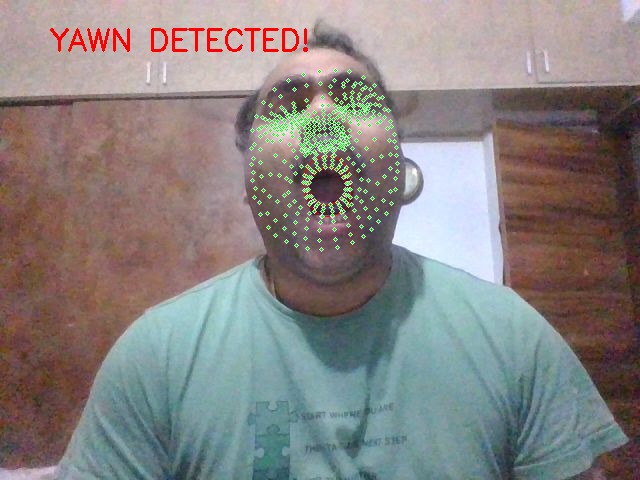

In [ ]:
from IPython.display import Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode
from google.colab.patches import cv2_imshow
import mediapipe as mp

# JavaScript: automatically capture one frame
def js_code():
    return Javascript('''
    async function captureFrame(quality) {
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Wait a short time to let camera adjust
      await new Promise(resolve => setTimeout(resolve, 2000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      video.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

display(js_code())

def capture_frame(filename='frame.jpg', quality=0.8):
    data = eval_js('captureFrame({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Mediapipe setup
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(refine_landmarks=True)
mp_drawing = mp.solutions.drawing_utils

def detect_yawn(image):
    h, w, _ = image.shape
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            # Draw lips
            mp_drawing.draw_landmarks(
                image,
                face_landmarks,
                mp_face_mesh.FACEMESH_LIPS,
                mp_drawing.DrawingSpec(color=(0,255,0), thickness=1, circle_radius=1),
                mp_drawing.DrawingSpec(color=(0,0,255), thickness=1)
            )
            # Simple MAR using two lip points
            top_lip = face_landmarks.landmark[13]
            bottom_lip = face_landmarks.landmark[14]
            mar = abs(int(bottom_lip.y * h) - int(top_lip.y * h))
            if mar > 15:
                cv2.putText(image, "YAWN DETECTED!", (50, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
            else:
                cv2.putText(image, f"MAR: {mar}", (50, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    return image

# Auto capture and detect
filename = capture_frame()
image = cv2.imread(filename)
processed = detect_yawn(image)
cv2_imshow(processed)